# EDA

## Data Loading

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [243]:
df = pd.read_excel('../data/dataset.xlsx')

In [244]:
# Reorder columns so kpi_x appears before kpi_y
df = df[['group_id', 'arm', 'visitor_id', 'arrival_time', 'exit_time', 
         'time_on_page_sec', 'exit_rate', 'kpi_y', 'kpi_x', 
         'scroll_depth_pct', 'page_load_time_ms']]

In [245]:
# Rename the kpi columns
df = df.rename(columns={'kpi_x': 'event_enrollment', 'kpi_y': 'cta_click'})

In [246]:
df.head()

,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,cta_click,event_enrollment,scroll_depth_pct,page_load_time_ms
0,TXB_23,pre,1,2026-02-22 23:31:43.201452,2026-02-22 23:33:13.78465,90.6,0,0,0,17.9,1966.6
1,TXB_23,pre,2,2026-02-23 00:29:00.126921,2026-02-23 00:29:30.137538,30.0,0,0,0,33.0,1033.4
2,TXB_23,pre,3,2026-02-23 00:42:38.603246,2026-02-23 00:43:32.468747,53.9,0,0,0,69.9,14458.0
3,TXB_23,pre,4,2026-02-23 00:43:09.494137,2026-02-23 00:49:38.542092,389.0,0,1,0,32.4,1296.5
4,TXB_23,pre,5,2026-02-23 00:45:13.195524,2026-02-23 00:48:07.005863,173.8,0,0,0,92.3,1022.2


## Missing Values Analysis


We have no missing values in our dataset

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1146 entries, 0 to 1145
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   group_id           1146 non-null   object 
 1   arm                1146 non-null   object 
 2   visitor_id         1146 non-null   int64  
 3   arrival_time       1146 non-null   object 
 4   exit_time          1146 non-null   object 
 5   time_on_page_sec   1146 non-null   float64
 6   exit_rate          1146 non-null   int64  
 7   cta_click          1146 non-null   int64  
 8   event_enrollment   1146 non-null   int64  
 9   scroll_depth_pct   1146 non-null   float64
 10  page_load_time_ms  1146 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 98.6+ KB


## Duplicate Values


In [248]:
# Step 1 - Duplicate check
print("Total rows:", len(df))
print("Unique visitor_ids:", df['visitor_id'].nunique())

duplicates = df[df.duplicated(subset='visitor_id', keep=False)]
print("\nRows with duplicate visitor_id:", len(duplicates))

if len(duplicates) > 0:
    print(duplicates.sort_values('visitor_id'))

Total rows: 1146
Unique visitor_ids: 1146

Rows with duplicate visitor_id: 0


##  Data Types & Timestamp Validation
Parse `arrival_time` and `exit_time` as proper datetimes, then derive `time_on_page_sec` from them and compare against the existing column to validate consistency.

In [249]:
# Step 2 - Data types & timestamp validation
df['arrival_time'] = pd.to_datetime(df['arrival_time'])
df['exit_time'] = pd.to_datetime(df['exit_time'])

# Derive time on page from timestamps and validate
time_derived = (df['exit_time'] - df['arrival_time']).dt.total_seconds()

diff = (df['time_on_page_sec'] - time_derived).abs()
print("Max difference (seconds):", diff.max())
print("Rows with difference > 1s:", (diff > 1).sum())

# Check for negative or zero durations
print("\nNegative durations:", (time_derived < 0).sum())
print("Zero durations:", (time_derived == 0).sum())

print("\nUpdated dtypes:\n", df.dtypes)

Max difference (seconds): 0.04997600000024249
Rows with difference > 1s: 0

Negative durations: 0
Zero durations: 0

Updated dtypes:
 group_id                     object
arm                          object
visitor_id                    int64
arrival_time         datetime64[ns]
exit_time            datetime64[ns]
time_on_page_sec            float64
exit_rate                     int64
cta_click                     int64
event_enrollment              int64
scroll_depth_pct            float64
page_load_time_ms           float64
dtype: object


## Distributions & Outliers
Visualize the distribution of numeric variables and flag potential outliers.

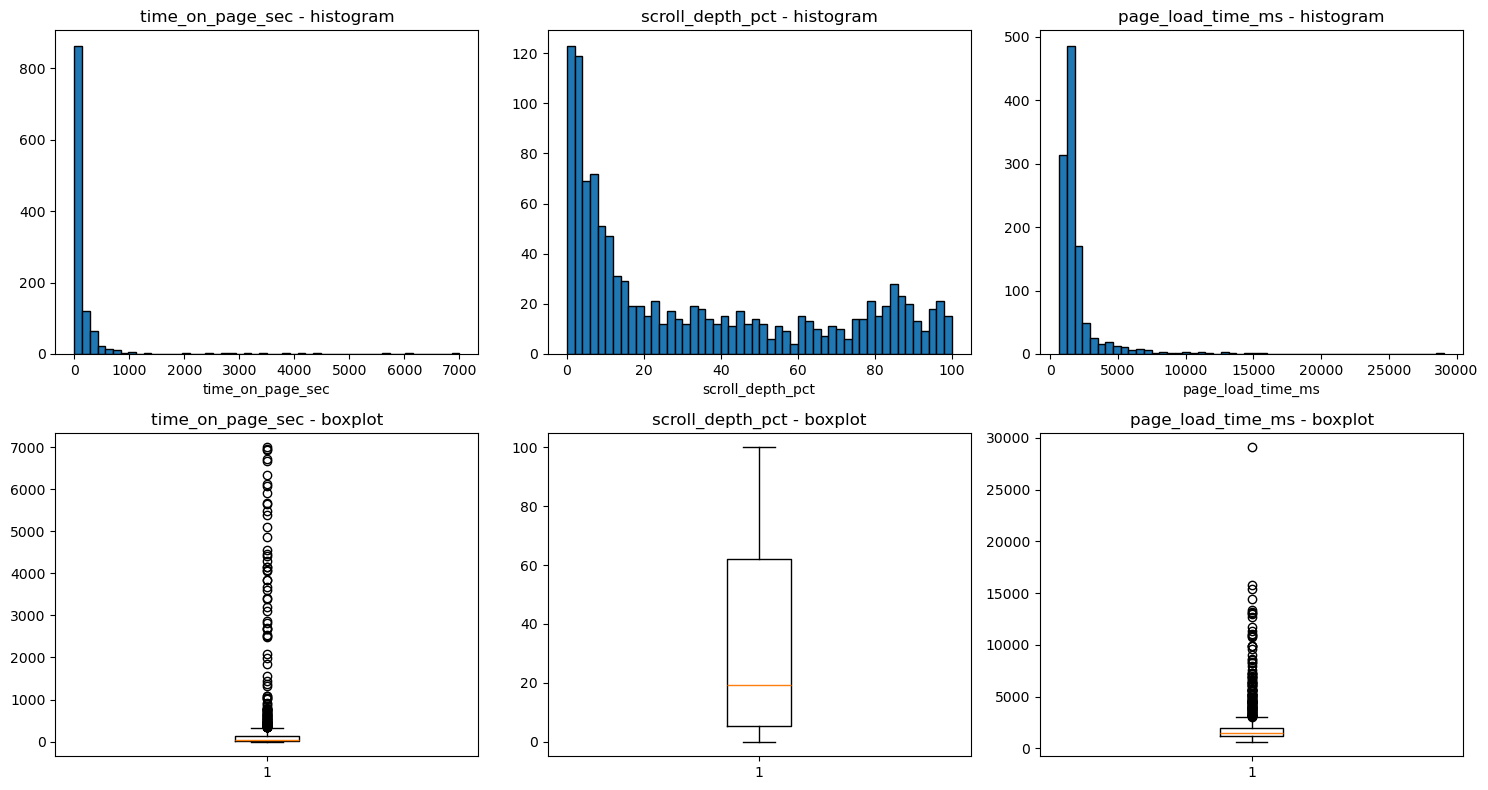

time_on_page_sec: 130 outliers (11.3%)
scroll_depth_pct: 0 outliers (0.0%)
page_load_time_ms: 123 outliers (10.7%)


In [250]:
# Step 3 - Distributions & Outliers
numeric_cols = ['time_on_page_sec', 'scroll_depth_pct', 'page_load_time_ms']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=50, edgecolor='black')
    axes[0, i].set_title(f'{col} - histogram')
    axes[0, i].set_xlabel(col)
    
    # Boxplot
    axes[1, i].boxplot(df[col], vert=True)
    axes[1, i].set_title(f'{col} - boxplot')

plt.tight_layout()
plt.show()

# IQR outlier count
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

## Balance Check
Verify that Control and Treatment groups are roughly the same size, and that key numeric variables are similarly distributed across arms before the experiment.

In [251]:
# Step 4 - Balance check
print("Arm counts:")
print(df['arm'].value_counts())
print("\nArm proportions:")
print(df['arm'].value_counts(normalize=True).round(3))

# Compare numeric variables across arms
numeric_cols = ['time_on_page_sec', 'scroll_depth_pct', 'page_load_time_ms']

df.groupby('arm')[numeric_cols].mean().round(2)

Arm counts:
arm
Control      403
Treatment    400
pre          343
Name: count, dtype: int64

Arm proportions:
arm
Control      0.352
Treatment    0.349
pre          0.299
Name: proportion, dtype: float64


,time_on_page_sec,scroll_depth_pct,page_load_time_ms
arm,,,
Control,240.68,28.72,1889.38
Treatment,225.91,35.75,1907.36
pre,302.76,36.71,2273.19


## Experiment Timeline
Visualize when each arm was active to confirm the pre-period and experiment period are properly separated in time.

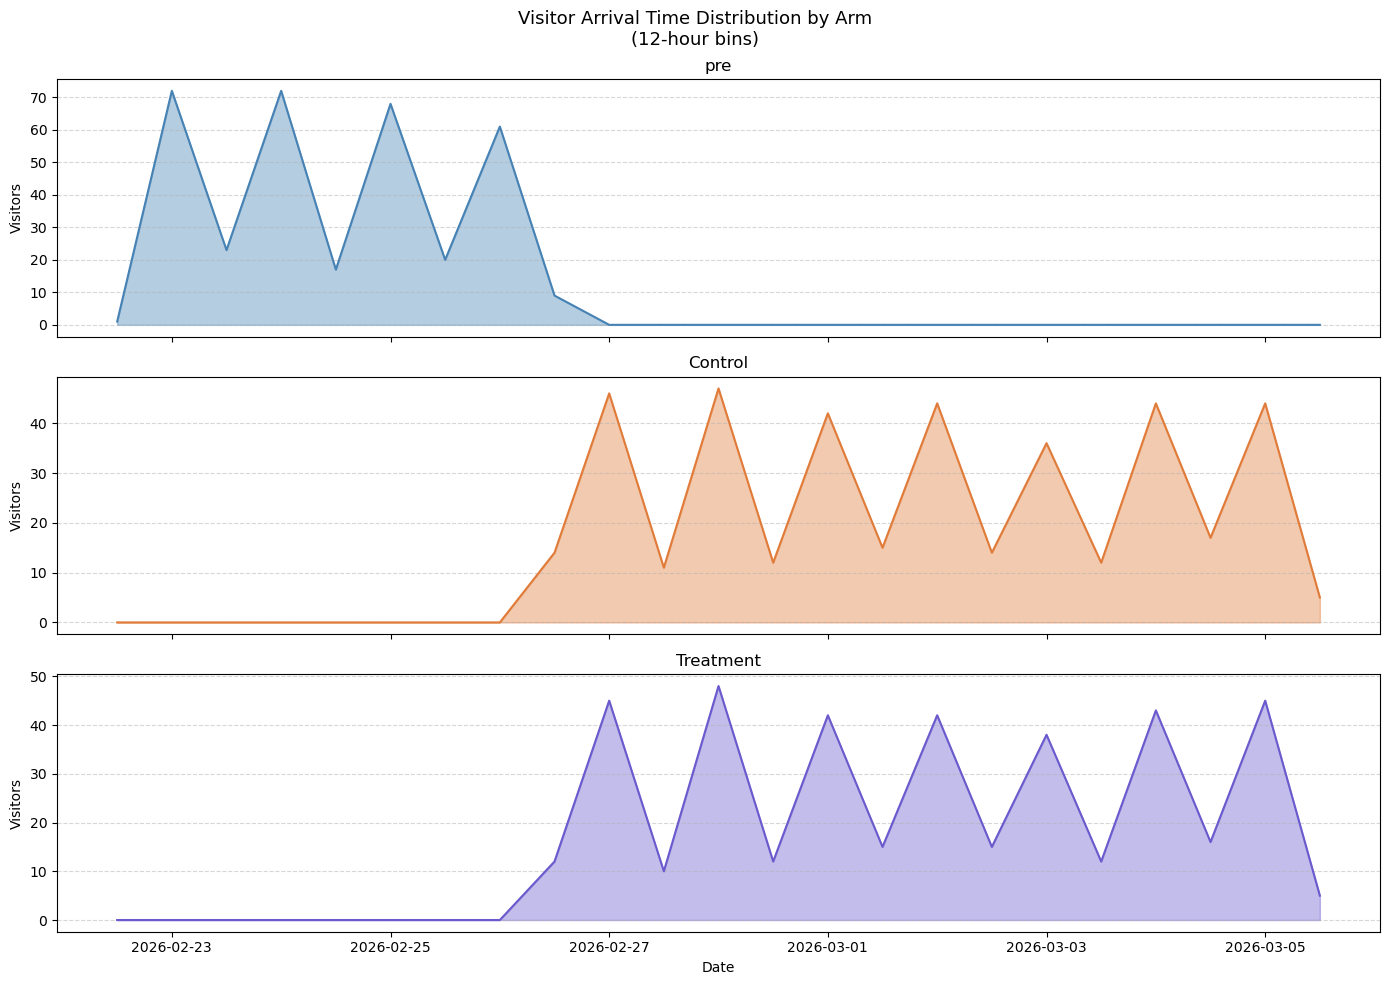

In [252]:
# Experiment timeline - area chart with separate arms
df_time = df.copy()
df_time['arrival_time'] = pd.to_datetime(df_time['arrival_time'])
df_time['time_bin'] = df_time['arrival_time'].dt.floor('12h')

timeline = df_time.groupby(['time_bin', 'arm']).size().unstack(fill_value=0)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = {'pre': 'steelblue', 'Control': '#E07B39', 'Treatment': '#6A5ACD'}

for ax, arm in zip(axes, ['pre', 'Control', 'Treatment']):
    if arm in timeline.columns:
        ax.fill_between(timeline.index, timeline[arm], alpha=0.4, color=colors[arm])
        ax.plot(timeline.index, timeline[arm], color=colors[arm], linewidth=1.5)
        ax.set_ylabel('Visitors')
        ax.set_title(arm)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Date')
fig.suptitle('Visitor Arrival Time Distribution by Arm\n(12-hour bins)', fontsize=13)
plt.tight_layout()
plt.show()





## Removing Invalid Records
Records where `event_enrollment = 1` but `cta_click = 0` are logically impossible — a visitor cannot enrol without first clicking the CTA. These rows are removed from the dataset.

In [253]:
# Removing invalid records
before = len(df)
df = df[~((df['event_enrollment'] == 1) & (df['cta_click'] == 0))]
after = len(df)

print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")

Rows removed: 47
Rows remaining: 1099


## Dealing with Outliers
Cap outliers in `time_on_page_sec` and `page_load_time_ms` at the 99th percentile to limit the influence of extreme values without dropping rows. 

In [ ]:
for col in ['time_on_page_sec', 'page_load_time_ms']:
    p99 = df[col].quantile(0.99)
    print(f"{col} — capping at 99th percentile: {p99:.1f}")
    print(f"  before — mean: {df[col].mean():.2f}, max: {df[col].max():.2f}")
    df[col] = df[col].clip(upper=p99)
    print(f"  after  — mean: {df[col].mean():.2f}, max: {df[col].max():.2f}\n")

time_on_page_sec — capping at 99th percentile: 5485.9
  before — mean: 249.73, max: 6996.40
  after  — mean: 240.88, max: 5485.88

page_load_time_ms — capping at 99th percentile: 11028.6
  before — mean: 2021.68, max: 29075.60
  after  — mean: 1983.65, max: 11028.59



## KPI Rates by Arm
Compare conversion rates for `kpi_x` and `kpi_y` across pre, Control, and Treatment arms.

KPI conversion rates (%):
           cta_click  event_enrollment
arm                                   
Control         21.2               2.3
Treatment       25.3               2.3
pre             25.8               2.5


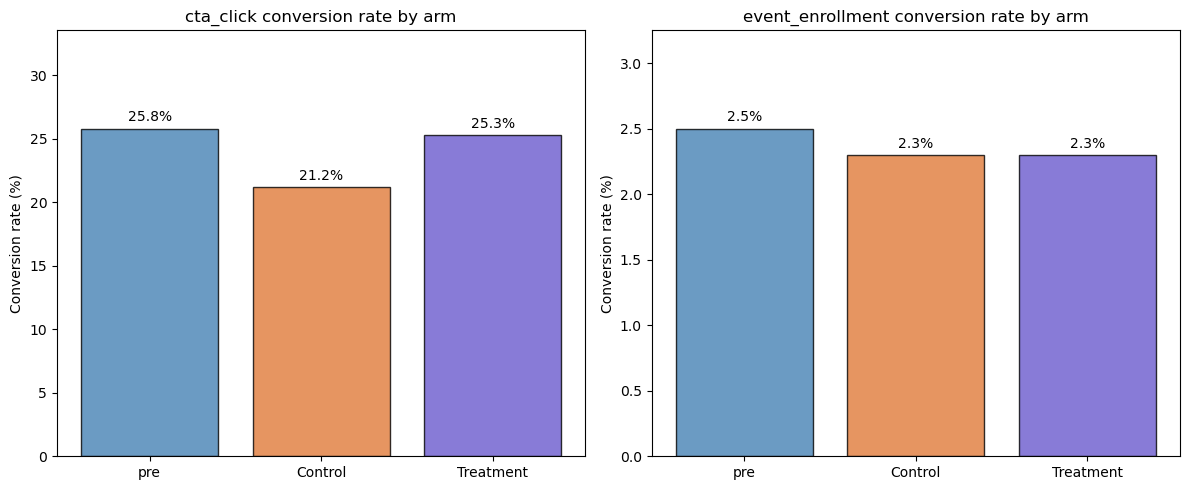

In [257]:
# Step 5 - KPI rates by arm
kpi_rates = df.groupby('arm')[['cta_click', 'event_enrollment']].mean().round(3) * 100

print("KPI conversion rates (%):")
print(kpi_rates)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

arm_order = ['pre', 'Control', 'Treatment']
colors = ['steelblue', '#E07B39', '#6A5ACD']

for ax, kpi in zip(axes, ['cta_click', 'event_enrollment']):
    values = [kpi_rates.loc[arm, kpi] for arm in arm_order]
    
    bars = ax.bar(arm_order, values, color=colors, edgecolor='black', alpha=0.8)
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_title(f'{kpi} conversion rate by arm')
    ax.set_ylabel('Conversion rate (%)')
    ax.set_ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.show()

The treatment drove a **+4.1pp lift in CTA clicks** (21.2% → 25.3%) but had **no impact on enrolment** (2.3% in both Control and Treatment). The extra clicks did not translate into enrolments, suggesting there is a friction point between clicking the CTA and completing the enrolment process.

## Step 6 - Correlation Analysis
Explore whether `scroll_depth_pct`, `time_on_page_sec`, and `page_load_time_ms` correlate with `cta_click` and `event_enrollment`.

                   time_on_page_sec  scroll_depth_pct  page_load_time_ms  \
time_on_page_sec               1.00              0.10              -0.01   
scroll_depth_pct               0.10              1.00               0.06   
page_load_time_ms             -0.01              0.06               1.00   
cta_click                      0.08              0.19              -0.02   
event_enrollment               0.04              0.05              -0.04   

                   cta_click  event_enrollment  
time_on_page_sec        0.08              0.04  
scroll_depth_pct        0.19              0.05  
page_load_time_ms      -0.02             -0.04  
cta_click               1.00              0.28  
event_enrollment        0.28              1.00  


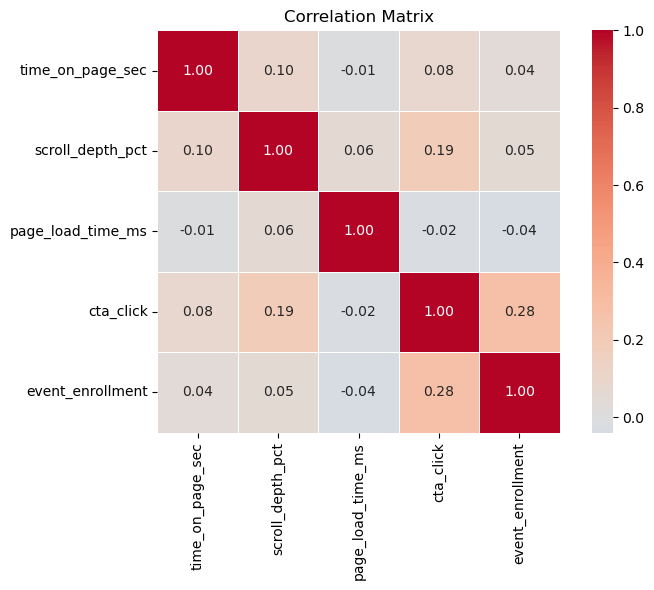

In [258]:
# Step 6 - Correlation analysis
numeric_cols = ['time_on_page_sec', 'scroll_depth_pct', 'page_load_time_ms', 'cta_click', 'event_enrollment']

# Correlation matrix
corr = df[numeric_cols].corr().round(2)
print(corr)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Correlation Analysis - Interpretation

- **`scroll_depth_pct`** is the strongest behavioral predictor of `cta_click` (0.19) — users who scroll more are more likely to click the CTA. However, it barely predicts `event_enrollment` (0.05), suggesting enrolment depends on factors beyond page engagement.

- **`cta_click` and `event_enrollment`** now correlate at 0.28, which is much more sensible than before removing the invalid records (0.08) — confirming the data cleaning was necessary.

- **`page_load_time_ms`** has a slightly negative effect on both KPIs (-0.02 and -0.04) — slower load times marginally hurt conversions, but the effect is minimal.

- **`time_on_page_sec`** is weakly correlated with both KPIs (0.08 and 0.04) — time spent on page alone does not drive conversions.

- Overall, none of the behavioral variables strongly predict `event_enrollment`, suggesting enrolment may be driven more by external factors such as user intent or campaign targeting than by on-page behavior.

## Exporting Dataset

In [259]:
# Export final dataset
df.to_excel(r'C:\Users\fmdmn\Desktop\TXB_GROUP23\data\df_after_EDA.xlsx', index=False)
print("Dataset exported successfully!")

Dataset exported successfully!
